# Membership

### 파일 불러오기

In [2]:
import pandas as pd
from pathlib import Path

# 파일 경로 
file_path = Path(r"C:\myCode\ott-churn-prediction\_data\02_interim\260430_membership_v1(이상치, 이름변경)\Membership_v1.csv")

df = pd.read_csv(file_path)

print("데이터 타입 및 결측치 정보 확인")
print(df.info())

데이터 타입 및 결측치 정보 확인
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17876 entries, 0 to 17875
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   USER_KEY            17876 non-null  object 
 1   product_code        17876 non-null  object 
 2   price               17876 non-null  float64
 3   billing_method      17876 non-null  int64  
 4   max_screen          17876 non-null  int64  
 5   is_promotion        17876 non-null  int64  
 6   is_churn_prevented  17876 non-null  int64  
 7   is_repurchase       17876 non-null  int64  
 8   payment_device      17876 non-null  object 
 9   is_user_verified    17876 non-null  int64  
 10  gender              17876 non-null  object 
 11  age                 17876 non-null  int64  
 12  reg_date            17876 non-null  object 
 13  reg_hour            17876 non-null  int64  
 14  end_date            17876 non-null  object 
dtypes: float64(1), int64(8), object(6)

### 1. max_screen

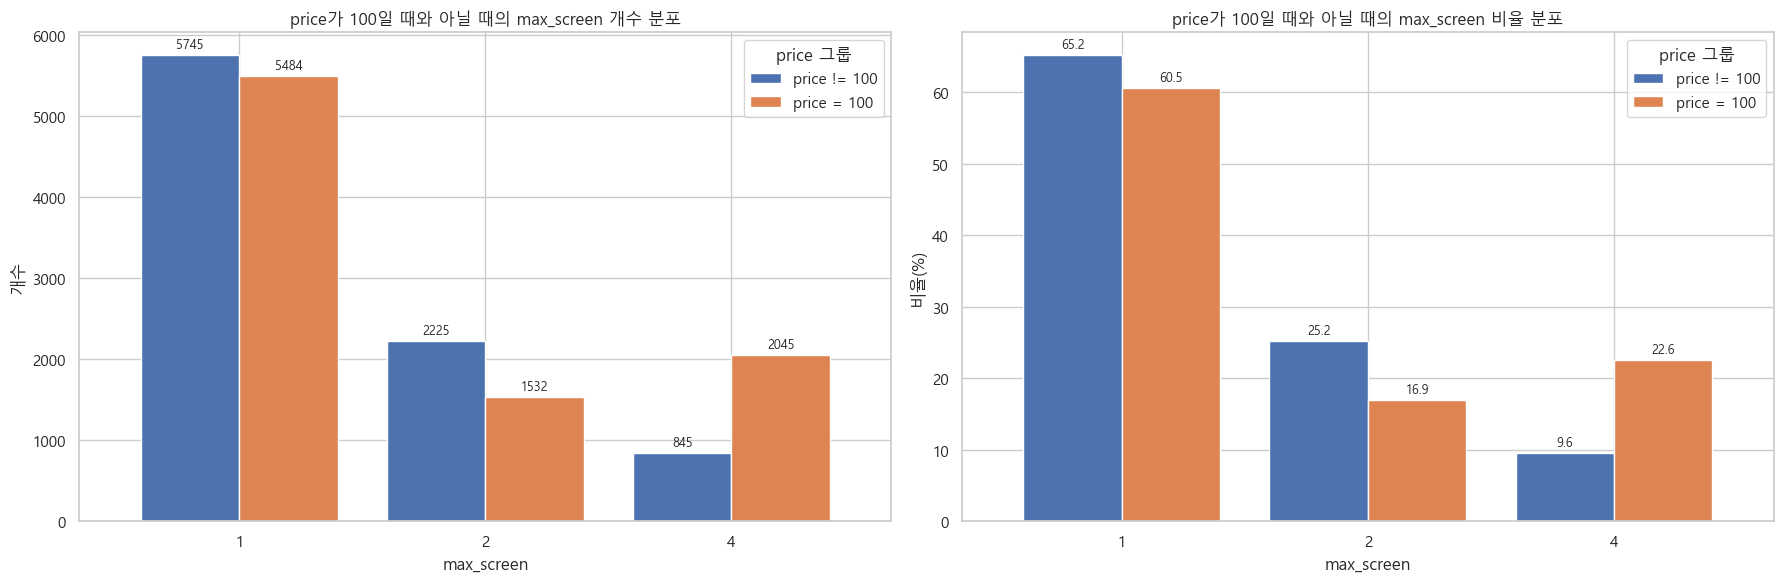

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 한글 폰트 후보 목록
font_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"]

# 설치 폰트 확인
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 사용할 폰트 선택
selected_font = next((font for font in font_candidates if font in available_fonts), None)

# 폰트 적용
if selected_font is not None:
    plt.rcParams["font.family"] = selected_font
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다.")

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 비교용 데이터 생성
plot_df = df[["price", "max_screen"]].copy()
plot_df["price"] = pd.to_numeric(plot_df["price"], errors="coerce")
plot_df = plot_df.dropna(subset=["price", "max_screen"])

# 가격 그룹 생성
plot_df["price_group"] = plot_df["price"].apply(
    lambda x: "price = 100" if x == 100 else "price != 100"
)

# 개수 분포표 생성
count_table = pd.crosstab(plot_df["max_screen"], plot_df["price_group"])

# 비율 분포표 생성
ratio_table = pd.crosstab(
    plot_df["max_screen"],
    plot_df["price_group"],
    normalize="columns"
) * 100


# 시각화 스타일 설정
sns.set_theme(style="whitegrid", font=selected_font if selected_font else None)

# 그래프 생성
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 개수 기준 그래프
count_table.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("price가 100일 때와 아닐 때의 max_screen 개수 분포")
axes[0].set_xlabel("max_screen")
axes[0].set_ylabel("개수")
axes[0].legend(title="price 그룹")
axes[0].tick_params(axis="x", rotation=0)

# 개수 라벨 추가
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=3, fontsize=9)

# 비율 기준 그래프
ratio_table.plot(kind="bar", ax=axes[1], width=0.8)
axes[1].set_title("price가 100일 때와 아닐 때의 max_screen 비율 분포")
axes[1].set_xlabel("max_screen")
axes[1].set_ylabel("비율(%)")
axes[1].legend(title="price 그룹")
axes[1].tick_params(axis="x", rotation=0)

# 비율 라벨 추가
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


### 2. is_churn_prevented

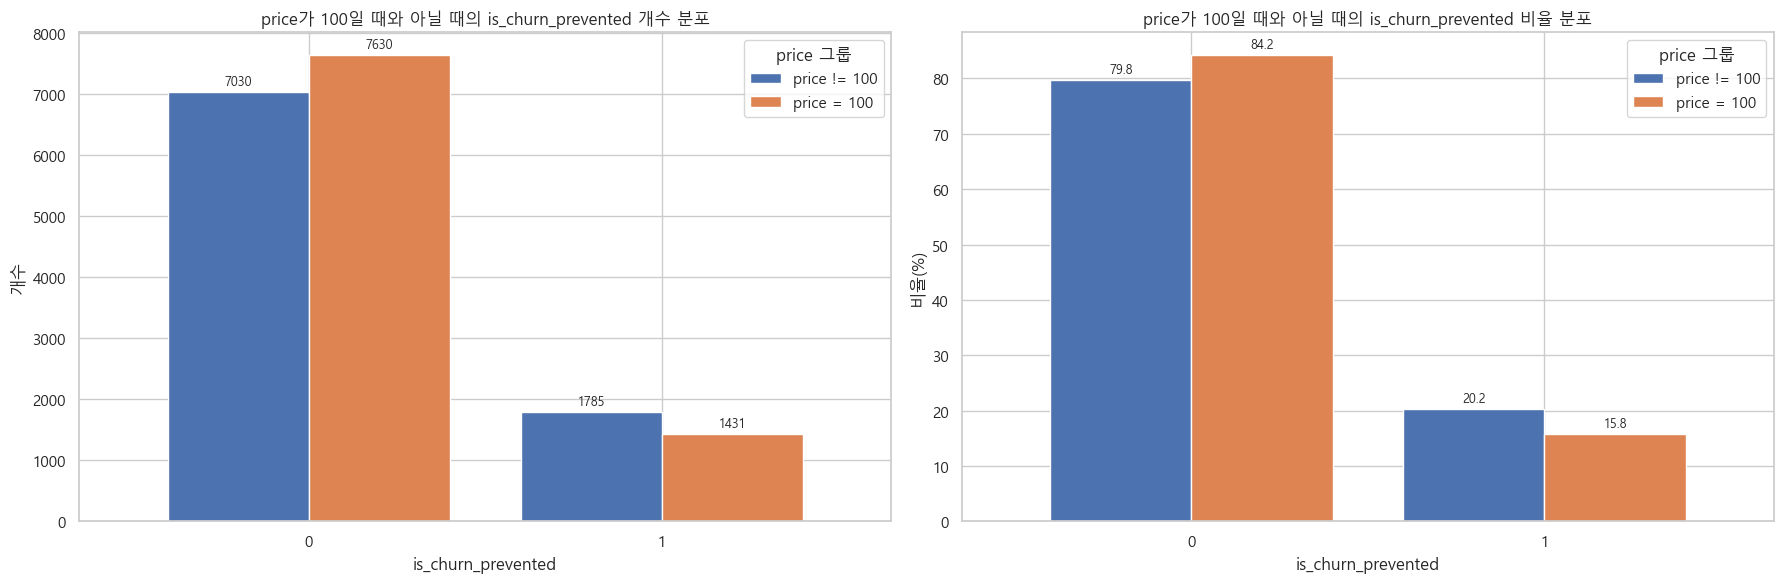

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 비교용 데이터 생성
plot_df = df[["price", "is_churn_prevented"]].copy()
plot_df["price"] = pd.to_numeric(plot_df["price"], errors="coerce")
plot_df = plot_df.dropna(subset=["price", "is_churn_prevented"])

# 가격 그룹 생성
plot_df["price_group"] = plot_df["price"].apply(
    lambda x: "price = 100" if x == 100 else "price != 100"
)

# 개수 분포표 생성
count_table = pd.crosstab(plot_df["is_churn_prevented"], plot_df["price_group"])

# 비율 분포표 생성
ratio_table = pd.crosstab(
    plot_df["is_churn_prevented"],
    plot_df["price_group"],
    normalize="columns"
) * 100

# 시각화 스타일 설정
sns.set_theme(style="whitegrid", font=selected_font if selected_font else None)

# 그래프 생성
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 개수 기준 그래프
count_table.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("price가 100일 때와 아닐 때의 is_churn_prevented 개수 분포")
axes[0].set_xlabel("is_churn_prevented")
axes[0].set_ylabel("개수")
axes[0].legend(title="price 그룹")
axes[0].tick_params(axis="x", rotation=0)

# 개수 라벨 추가
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=3, fontsize=9)

# 비율 기준 그래프
ratio_table.plot(kind="bar", ax=axes[1], width=0.8)
axes[1].set_title("price가 100일 때와 아닐 때의 is_churn_prevented 비율 분포")
axes[1].set_xlabel("is_churn_prevented")
axes[1].set_ylabel("비율(%)")
axes[1].legend(title="price 그룹")
axes[1].tick_params(axis="x", rotation=0)

# 비율 라벨 추가
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


### 3. is_repurchase

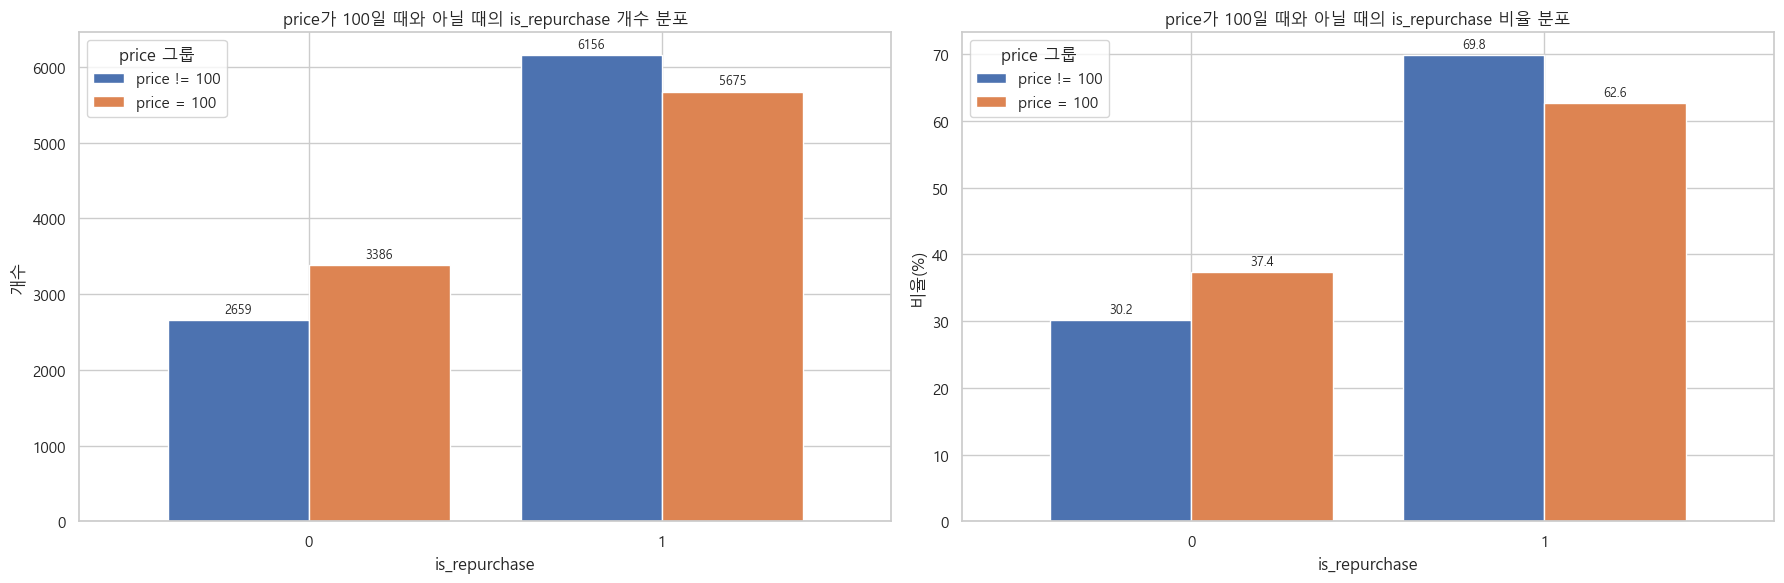

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 비교용 데이터 생성
plot_df = df[["price", "is_repurchase"]].copy()
plot_df["price"] = pd.to_numeric(plot_df["price"], errors="coerce")
plot_df = plot_df.dropna(subset=["price", "is_repurchase"])

# 가격 그룹 생성
plot_df["price_group"] = plot_df["price"].apply(
    lambda x: "price = 100" if x == 100 else "price != 100"
)

# 개수 분포표 생성
count_table = pd.crosstab(plot_df["is_repurchase"], plot_df["price_group"])

# 비율 분포표 생성
ratio_table = pd.crosstab(
    plot_df["is_repurchase"],
    plot_df["price_group"],
    normalize="columns"
) * 100

# 시각화 스타일 설정
sns.set_theme(style="whitegrid", font=selected_font if selected_font else None)

# 그래프 생성
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 개수 기준 그래프
count_table.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("price가 100일 때와 아닐 때의 is_repurchase 개수 분포")
axes[0].set_xlabel("is_repurchase")
axes[0].set_ylabel("개수")
axes[0].legend(title="price 그룹")
axes[0].tick_params(axis="x", rotation=0)

# 개수 라벨 추가
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=3, fontsize=9)

# 비율 기준 그래프
ratio_table.plot(kind="bar", ax=axes[1], width=0.8)
axes[1].set_title("price가 100일 때와 아닐 때의 is_repurchase 비율 분포")
axes[1].set_xlabel("is_repurchase")
axes[1].set_ylabel("비율(%)")
axes[1].legend(title="price 그룹")
axes[1].tick_params(axis="x", rotation=0)

# 비율 라벨 추가
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


### 4. is_user_verified

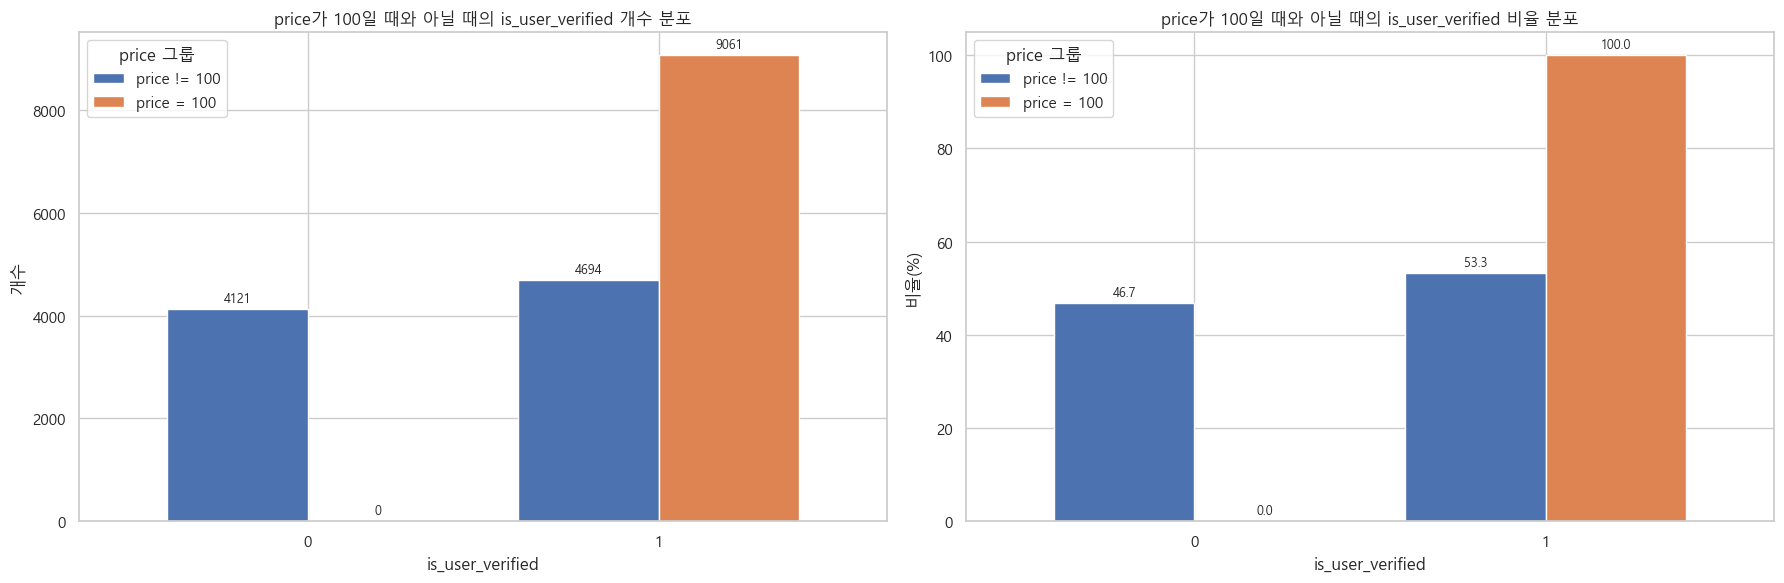

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 비교용 데이터 생성
plot_df = df[["price", "is_user_verified"]].copy()
plot_df["price"] = pd.to_numeric(plot_df["price"], errors="coerce")
plot_df = plot_df.dropna(subset=["price", "is_user_verified"])

# 가격 그룹 생성
plot_df["price_group"] = plot_df["price"].apply(
    lambda x: "price = 100" if x == 100 else "price != 100"
)

# 개수 분포표 생성
count_table = pd.crosstab(plot_df["is_user_verified"], plot_df["price_group"])

# 비율 분포표 생성
ratio_table = pd.crosstab(
    plot_df["is_user_verified"],
    plot_df["price_group"],
    normalize="columns"
) * 100

# 시각화 스타일 설정
sns.set_theme(style="whitegrid", font=selected_font if selected_font else None)

# 그래프 생성
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 개수 기준 그래프
count_table.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("price가 100일 때와 아닐 때의 is_user_verified 개수 분포")
axes[0].set_xlabel("is_user_verified")
axes[0].set_ylabel("개수")
axes[0].legend(title="price 그룹")
axes[0].tick_params(axis="x", rotation=0)

# 개수 라벨 추가
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=3, fontsize=9)

# 비율 기준 그래프
ratio_table.plot(kind="bar", ax=axes[1], width=0.8)
axes[1].set_title("price가 100일 때와 아닐 때의 is_user_verified 비율 분포")
axes[1].set_xlabel("is_user_verified")
axes[1].set_ylabel("비율(%)")
axes[1].legend(title="price 그룹")
axes[1].tick_params(axis="x", rotation=0)

# 비율 라벨 추가
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


### 5. gender

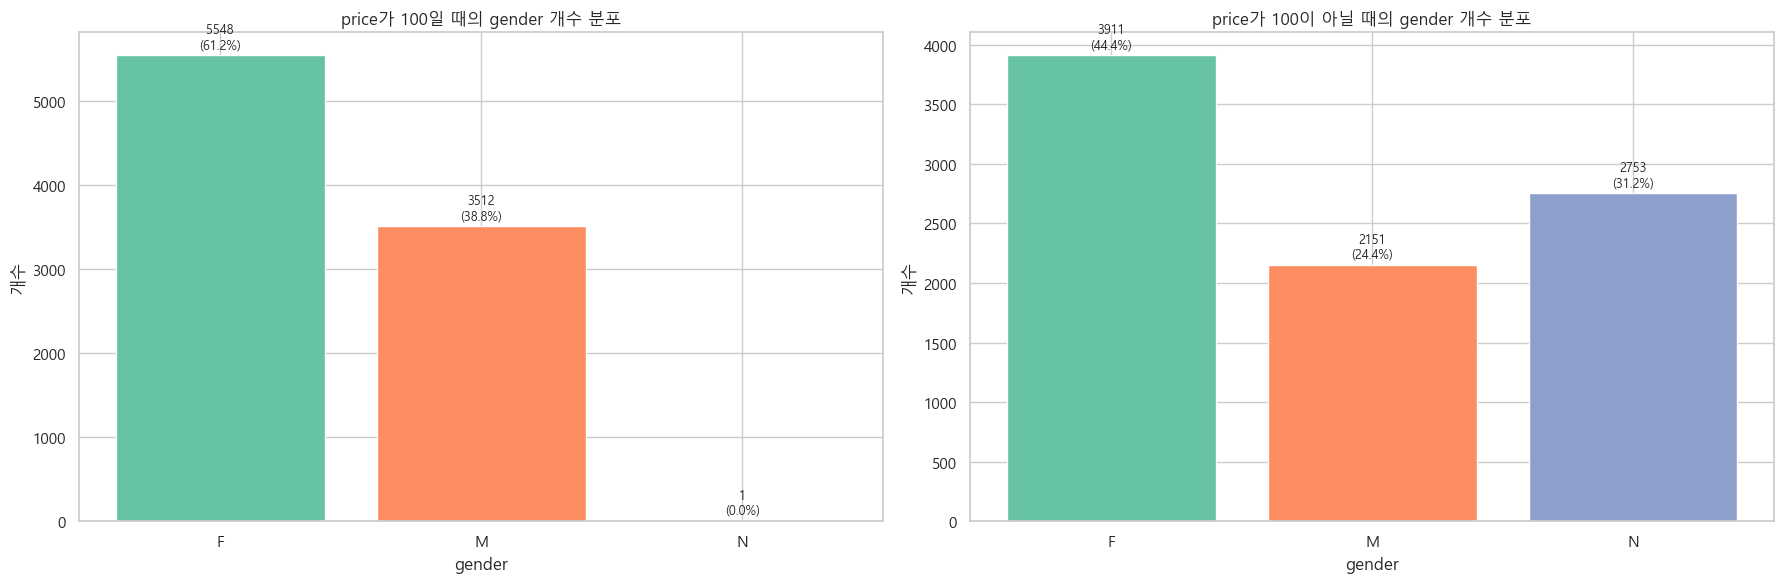

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 비교용 데이터 생성
plot_df = df[["price", "gender"]].copy()
plot_df["price"] = pd.to_numeric(plot_df["price"], errors="coerce")
plot_df = plot_df.dropna(subset=["price", "gender"])

# 가격 그룹 생성
plot_df["price_group"] = plot_df["price"].apply(
    lambda x: "price = 100" if x == 100 else "price != 100"
)

# gender 고정 순서 생성
gender_order = sorted(plot_df["gender"].astype(str).unique())
plot_df["gender"] = plot_df["gender"].astype(str)

# 그룹별 개수 생성
gender_100_count = (
    plot_df[plot_df["price_group"] == "price = 100"]["gender"]
    .value_counts()
    .reindex(gender_order, fill_value=0)
)

gender_not_100_count = (
    plot_df[plot_df["price_group"] == "price != 100"]["gender"]
    .value_counts()
    .reindex(gender_order, fill_value=0)
)

# 그룹별 비율 생성
gender_100_ratio = (gender_100_count / gender_100_count.sum() * 100).fillna(0)
gender_not_100_ratio = (gender_not_100_count / gender_not_100_count.sum() * 100).fillna(0)

# 색상 팔레트 생성
palette = sns.color_palette("Set2", n_colors=len(gender_order))

# 시각화 스타일 설정
sns.set_theme(style="whitegrid", font=selected_font if selected_font else None)

# 그래프 생성
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# price = 100 그래프
bars_100 = axes[0].bar(
    gender_order,
    gender_100_count.values,
    color=palette,
    width=0.8
)
axes[0].set_title("price가 100일 때의 gender 개수 분포")
axes[0].set_xlabel("gender")
axes[0].set_ylabel("개수")
axes[0].tick_params(axis="x", rotation=0)

# price = 100 라벨 추가
labels_100 = [
    f"{count:.0f}\n({ratio:.1f}%)"
    for count, ratio in zip(gender_100_count.values, gender_100_ratio.values)
]
axes[0].bar_label(bars_100, labels=labels_100, padding=3, fontsize=9)

# price != 100 그래프
bars_not_100 = axes[1].bar(
    gender_order,
    gender_not_100_count.values,
    color=palette,
    width=0.8
)
axes[1].set_title("price가 100이 아닐 때의 gender 개수 분포")
axes[1].set_xlabel("gender")
axes[1].set_ylabel("개수")
axes[1].tick_params(axis="x", rotation=0)

# price != 100 라벨 추가
labels_not_100 = [
    f"{count:.0f}\n({ratio:.1f}%)"
    for count, ratio in zip(gender_not_100_count.values, gender_not_100_ratio.values)
]
axes[1].bar_label(bars_not_100, labels=labels_not_100, padding=3, fontsize=9)

plt.tight_layout()
plt.show()


### 6. age

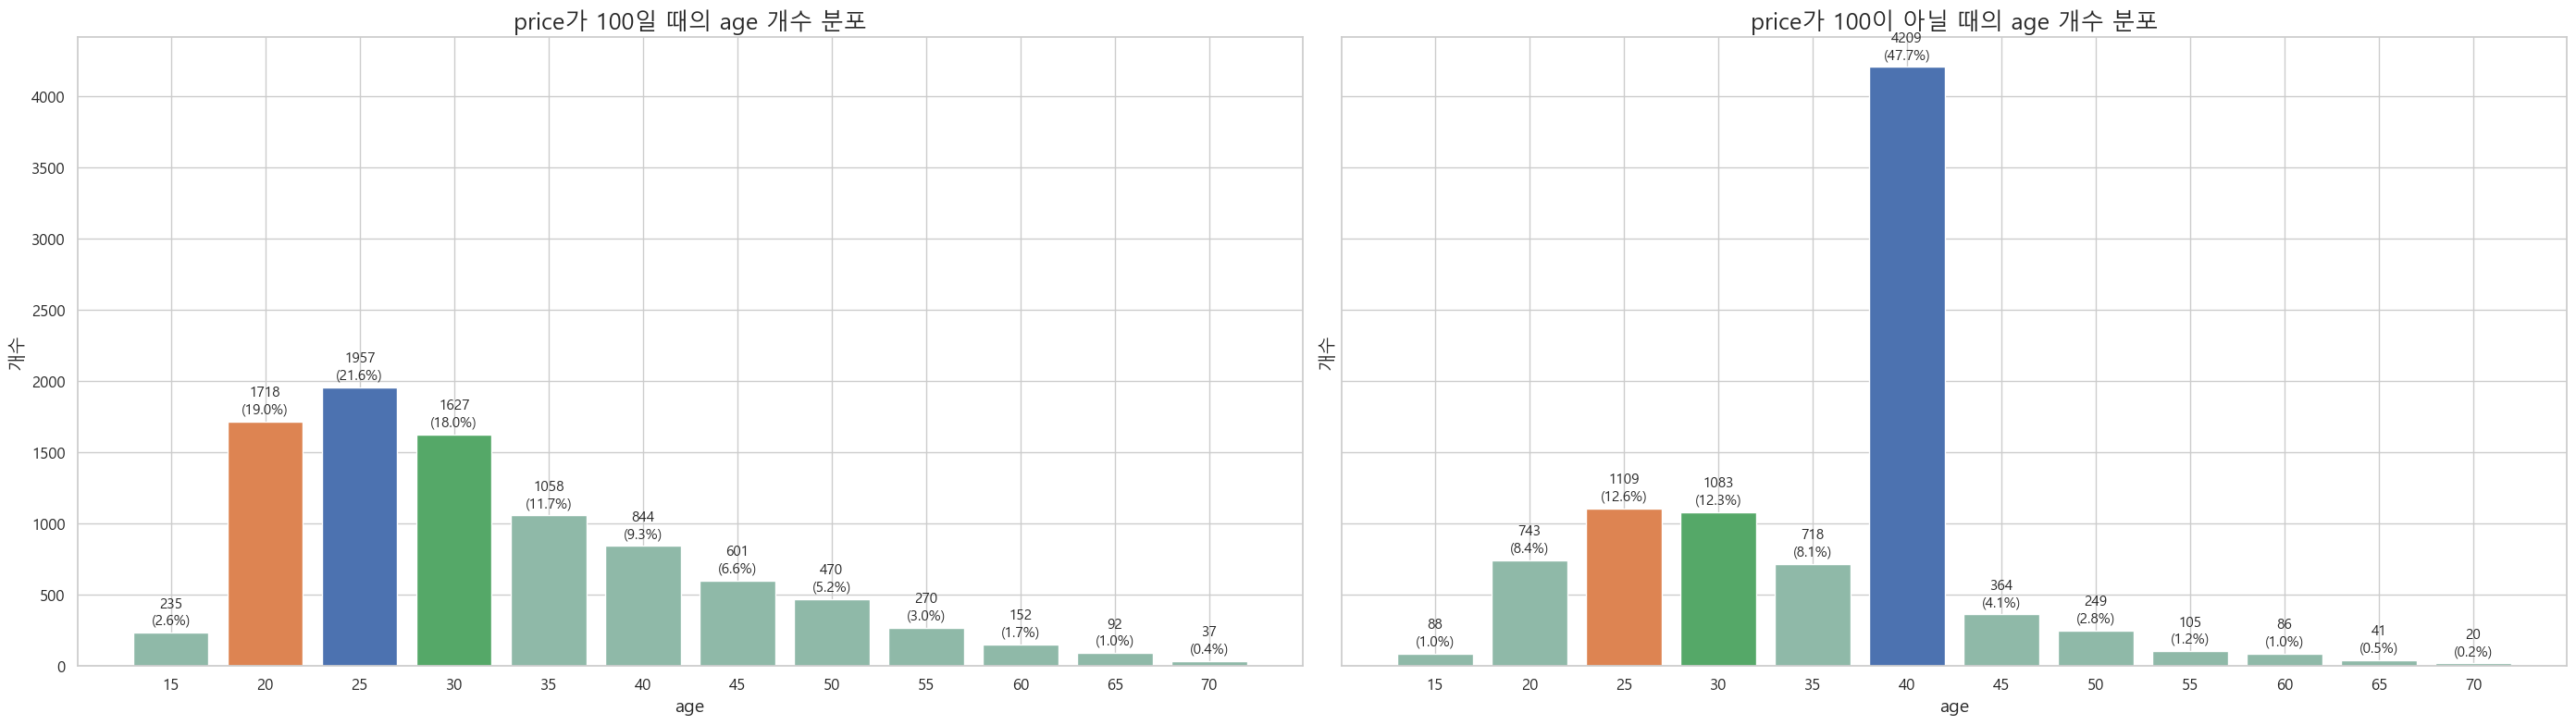

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 비교용 데이터 생성
plot_df = df[["price", "age"]].copy()
plot_df["price"] = pd.to_numeric(plot_df["price"], errors="coerce")
plot_df["age"] = pd.to_numeric(plot_df["age"], errors="coerce")
plot_df = plot_df.dropna(subset=["price", "age"])

# age 정수형 변환
plot_df["age"] = plot_df["age"].astype(int)

# 가격 그룹 생성
plot_df["price_group"] = plot_df["price"].apply(
    lambda x: "price = 100" if x == 100 else "price != 100"
)

# age 고정 순서 생성
age_order = sorted(plot_df["age"].unique())

# 그룹별 개수 생성
age_100_count = (
    plot_df[plot_df["price_group"] == "price = 100"]["age"]
    .value_counts()
    .reindex(age_order, fill_value=0)
)

age_not_100_count = (
    plot_df[plot_df["price_group"] == "price != 100"]["age"]
    .value_counts()
    .reindex(age_order, fill_value=0)
)

# 그룹별 비율 생성
age_100_ratio = (age_100_count / age_100_count.sum() * 100).fillna(0)
age_not_100_ratio = (age_not_100_count / age_not_100_count.sum() * 100).fillna(0)

# 각 그래프별 상위 3개 age 추출
top3_age_100 = age_100_count[age_100_count > 0].nlargest(3).index.tolist()
top3_age_not_100 = age_not_100_count[age_not_100_count > 0].nlargest(3).index.tolist()

# 색상 설정
base_color = "#8FB9A8"
highlight_colors = ["#4C72B0", "#DD8452", "#55A868"]

# price = 100 색상 생성
color_map_100 = {}
for i, age in enumerate(top3_age_100):
    color_map_100[age] = highlight_colors[i]

colors_100 = [
    color_map_100.get(age, base_color)
    for age in age_order
]

# price != 100 색상 생성
color_map_not_100 = {}
for i, age in enumerate(top3_age_not_100):
    color_map_not_100[age] = highlight_colors[i]

colors_not_100 = [
    color_map_not_100.get(age, base_color)
    for age in age_order
]

# 시각화 스타일 설정
sns.set_theme(style="whitegrid", font=selected_font if selected_font else None)

# 그래프 생성
fig, axes = plt.subplots(1, 2, figsize=(28, 8), sharey=True)

# price = 100 그래프
bars_100 = axes[0].bar(
    [str(age) for age in age_order],
    age_100_count.values,
    color=colors_100,
    width=0.8
)
axes[0].set_title("price가 100일 때의 age 개수 분포", fontsize=18)
axes[0].set_xlabel("age", fontsize=14)
axes[0].set_ylabel("개수", fontsize=14)
axes[0].tick_params(axis="x", rotation=0, labelsize=12)
axes[0].tick_params(axis="y", labelsize=12)

# price = 100 라벨 추가
labels_100 = [
    f"{count:.0f}\n({ratio:.1f}%)"
    for count, ratio in zip(age_100_count.values, age_100_ratio.values)
]
axes[0].bar_label(bars_100, labels=labels_100, padding=3, fontsize=11)

# price != 100 그래프
bars_not_100 = axes[1].bar(
    [str(age) for age in age_order],
    age_not_100_count.values,
    color=colors_not_100,
    width=0.8
)
axes[1].set_title("price가 100이 아닐 때의 age 개수 분포", fontsize=18)
axes[1].set_xlabel("age", fontsize=14)
axes[1].set_ylabel("개수", fontsize=14)
axes[1].tick_params(axis="x", rotation=0, labelsize=12)
axes[1].tick_params(axis="y", labelsize=12)

# price != 100 라벨 추가
labels_not_100 = [
    f"{count:.0f}\n({ratio:.1f}%)"
    for count, ratio in zip(age_not_100_count.values, age_not_100_ratio.values)
]
axes[1].bar_label(bars_not_100, labels=labels_not_100, padding=3, fontsize=11)

plt.tight_layout()
plt.show()


# View_History

### 파일 불러오기

In [9]:
import pandas as pd

file_path = r"C:\myCode\ott-churn-prediction\kwon.donggeun\data\02_interim\260504_promotion_split\promotion_0_view_history_v2.csv"

VH_0 = pd.read_csv(file_path)

VH_0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50858 entries, 0 to 50857
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   USER_NUM         50858 non-null  int64
 1   MOVIE_NUM        50858 non-null  int64
 2   watch_time(min)  50858 non-null  int64
 3   watch_day        50858 non-null  int64
 4   watch_seq        50858 non-null  int64
dtypes: int64(5)
memory usage: 1.9 MB


In [10]:
import pandas as pd

file_path = r"C:\myCode\ott-churn-prediction\kwon.donggeun\data\02_interim\260504_promotion_split\promotion_1_view_history_v2.csv"

VH_1 = pd.read_csv(file_path)

VH_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54370 entries, 0 to 54369
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   USER_NUM         54370 non-null  int64
 1   MOVIE_NUM        54370 non-null  int64
 2   watch_time(min)  54370 non-null  int64
 3   watch_day        54370 non-null  int64
 4   watch_seq        54370 non-null  int64
dtypes: int64(5)
memory usage: 2.1 MB


In [11]:
# VH_0의 고유 USER_NUM 추출
vh0_user_nums = VH_0["USER_NUM"].dropna().unique()

# VH_1의 고유 USER_NUM 추출
vh1_user_nums = VH_1["USER_NUM"].dropna().unique()

# 고유 USER_NUM 개수 계산
vh0_user_num_count = VH_0["USER_NUM"].nunique()
vh1_user_num_count = VH_1["USER_NUM"].nunique()

print("VH_0 고유 USER_NUM 개수:", vh0_user_num_count)
print("VH_1 고유 USER_NUM 개수:", vh1_user_num_count)

VH_0 고유 USER_NUM 개수: 7176
VH_1 고유 USER_NUM 개수: 7558


In [12]:
7176 +  7558

14734

### 1. watch_time(min)

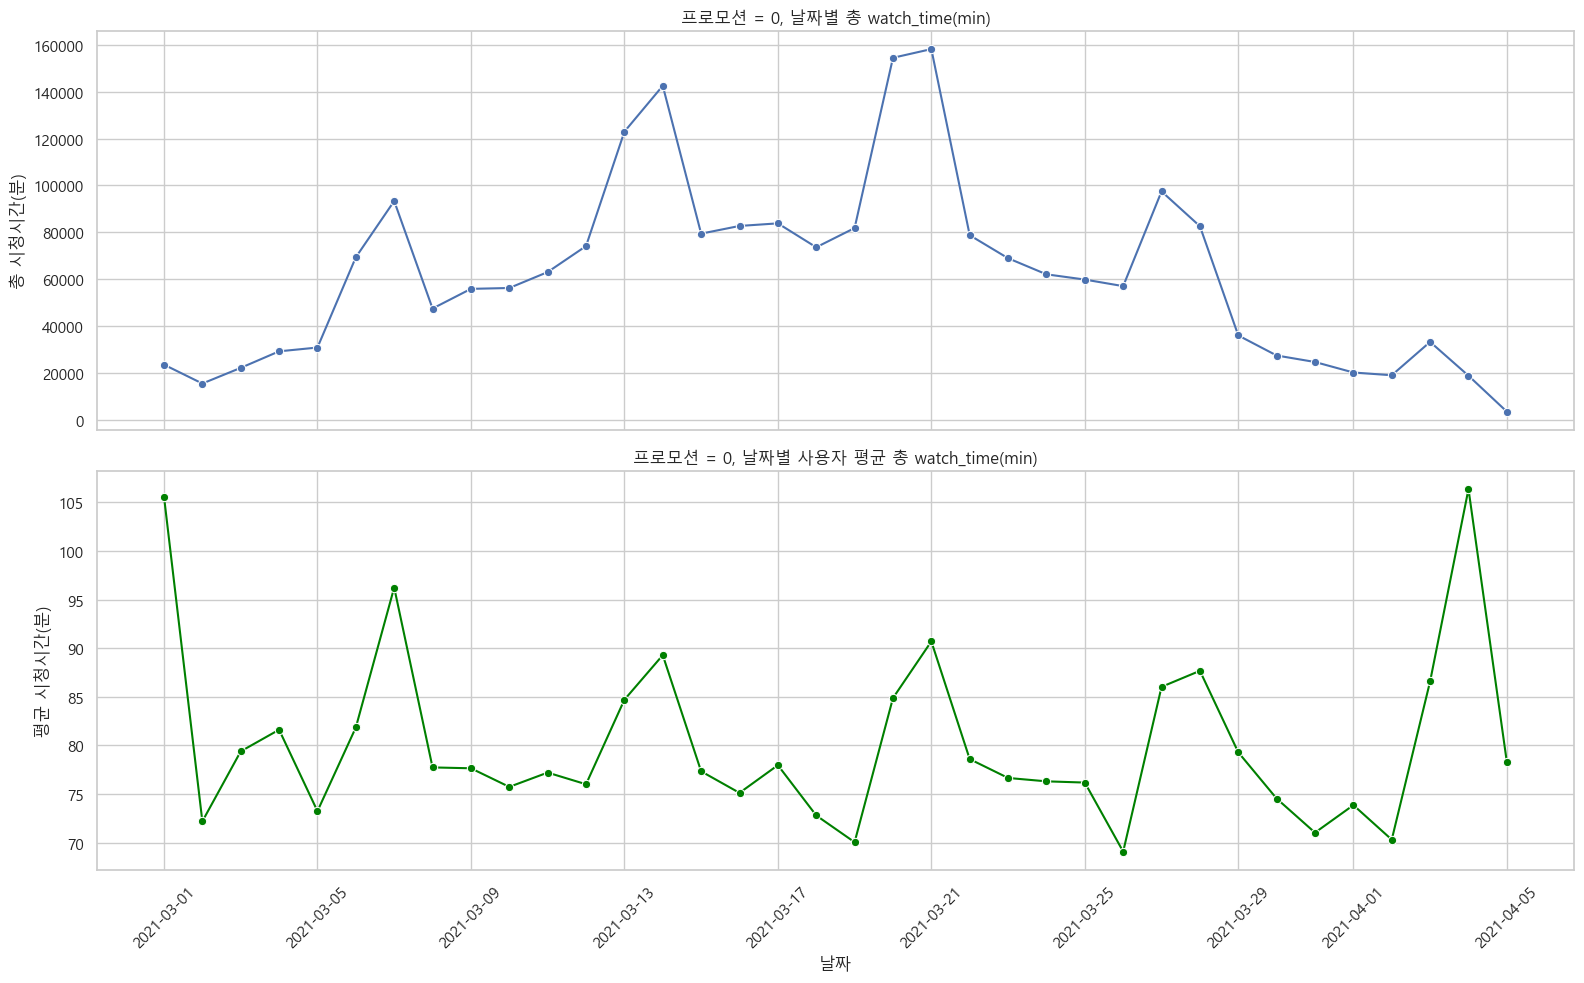

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글 폰트 설정 함수
def set_korean_font():
    font_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
    available_fonts = {f.name for f in fm.fontManager.ttflist}

    for font_name in font_candidates:
        if font_name in available_fonts:
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return

# 시각화 기본 설정
sns.set_style("whitegrid")
set_korean_font()

# 날짜 컬럼명 지정
date_col = "watch_day"

# 분석용 데이터 준비
tmp = VH_0[[date_col, "USER_NUM", "watch_time(min)"]].copy()

# 날짜형 변환
tmp[date_col] = pd.to_datetime(
    tmp[date_col].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

# 시청시간 숫자형 변환
tmp["watch_time(min)"] = pd.to_numeric(tmp["watch_time(min)"], errors="coerce")

# 결측 제거
tmp = tmp.dropna(subset=[date_col, "USER_NUM", "watch_time(min)"])

# 날짜 + 사용자 기준 총 시청시간 집계
user_day_summary = (
    tmp.groupby([date_col, "USER_NUM"], as_index=False)["watch_time(min)"]
    .agg(
        user_watch_time_sum="sum"
    )
)

# 날짜 기준 집계
day_summary = (
    user_day_summary.groupby(date_col, as_index=False)
    .agg(
        day_total_watch_time=("user_watch_time_sum", "sum"),
        day_avg_user_watch_time=("user_watch_time_sum", "mean")
    )
    .sort_values(date_col)
)

# 그래프 2개 시각화
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

sns.lineplot(
    data=day_summary,
    x=date_col,
    y="day_total_watch_time",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("프로모션 = 0, 날짜별 총 watch_time(min)")
axes[0].set_xlabel("")
axes[0].set_ylabel("총 시청시간(분)")

sns.lineplot(
    data=day_summary,
    x=date_col,
    y="day_avg_user_watch_time",
    marker="o",
    color="green",
    ax=axes[1]
)
axes[1].set_title("프로모션 = 0, 날짜별 사용자 평균 총 watch_time(min)")
axes[1].set_xlabel("날짜")
axes[1].set_ylabel("평균 시청시간(분)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


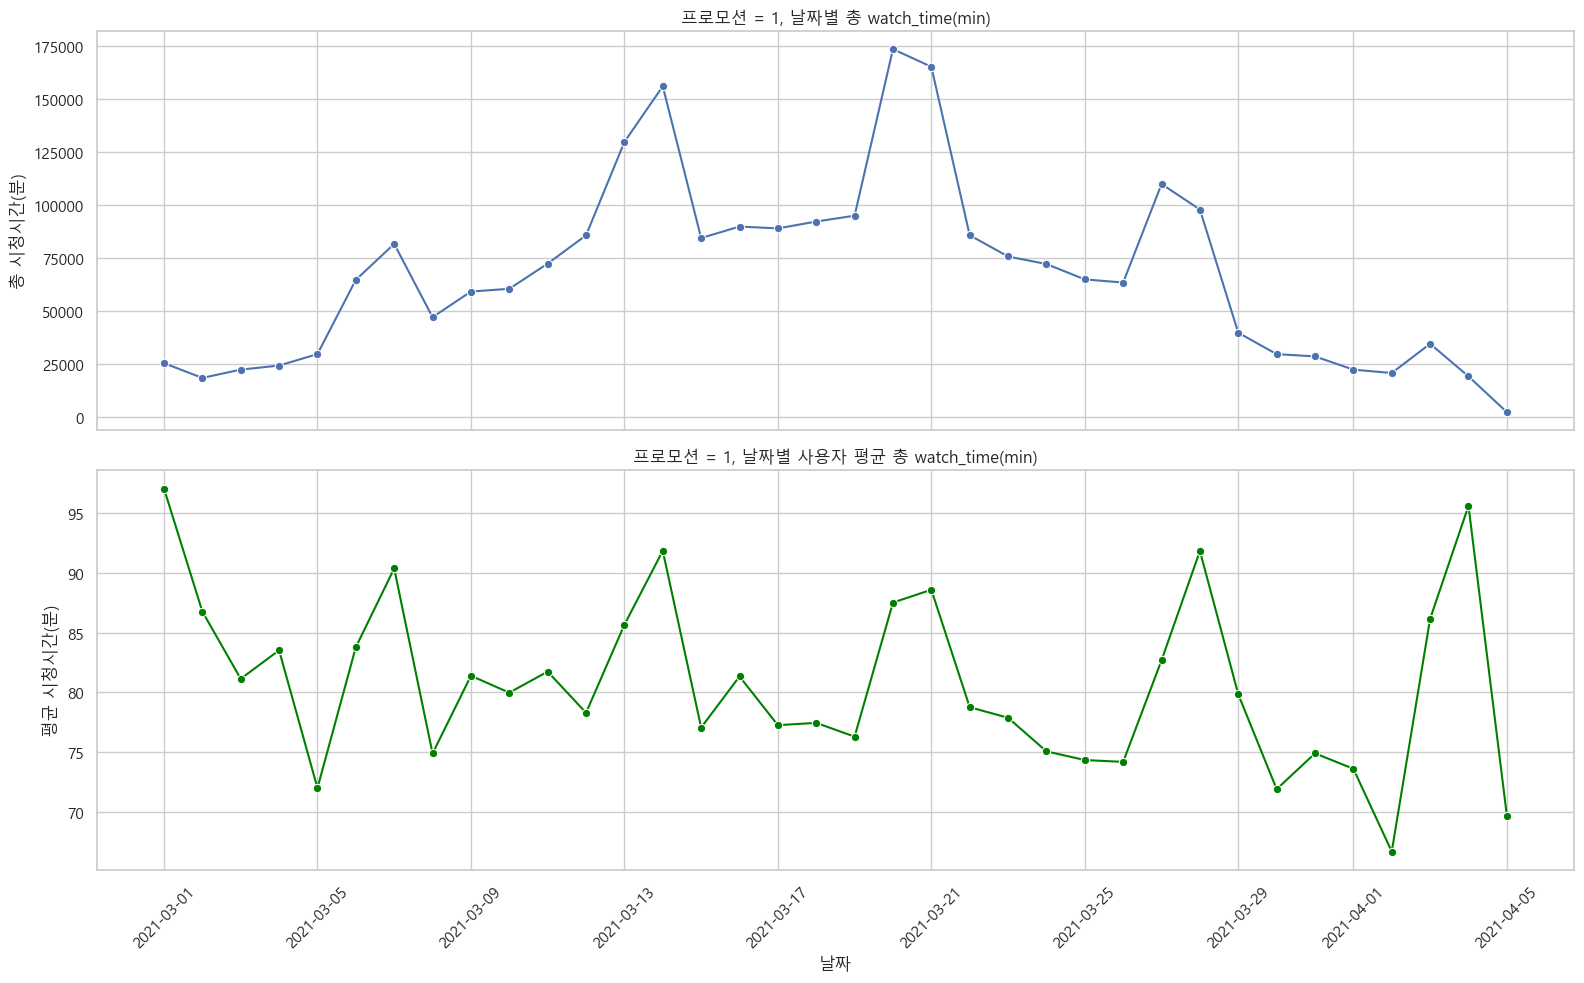

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글 폰트 설정 함수
def set_korean_font():
    font_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
    available_fonts = {f.name for f in fm.fontManager.ttflist}

    for font_name in font_candidates:
        if font_name in available_fonts:
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return

# 시각화 기본 설정
sns.set_style("whitegrid")
set_korean_font()

# 날짜 컬럼명 지정
date_col = "watch_day"

# 분석용 데이터 준비
tmp = VH_1[[date_col, "USER_NUM", "watch_time(min)"]].copy()

# 날짜형 변환
tmp[date_col] = pd.to_datetime(
    tmp[date_col].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

# 시청시간 숫자형 변환
tmp["watch_time(min)"] = pd.to_numeric(tmp["watch_time(min)"], errors="coerce")

# 결측 제거
tmp = tmp.dropna(subset=[date_col, "USER_NUM", "watch_time(min)"])

# 날짜 + 사용자 기준 총 시청시간 집계
user_day_summary = (
    tmp.groupby([date_col, "USER_NUM"], as_index=False)["watch_time(min)"]
    .agg(
        user_watch_time_sum="sum"
    )
)

# 날짜 기준 집계
day_summary = (
    user_day_summary.groupby(date_col, as_index=False)
    .agg(
        day_total_watch_time=("user_watch_time_sum", "sum"),
        day_avg_user_watch_time=("user_watch_time_sum", "mean")
    )
    .sort_values(date_col)
)

# 그래프 2개 시각화
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

sns.lineplot(
    data=day_summary,
    x=date_col,
    y="day_total_watch_time",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("프로모션 = 1, 날짜별 총 watch_time(min)")
axes[0].set_xlabel("")
axes[0].set_ylabel("총 시청시간(분)")

sns.lineplot(
    data=day_summary,
    x=date_col,
    y="day_avg_user_watch_time",
    marker="o",
    color="green",
    ax=axes[1]
)
axes[1].set_title("프로모션 = 1, 날짜별 사용자 평균 총 watch_time(min)")
axes[1].set_xlabel("날짜")
axes[1].set_ylabel("평균 시청시간(분)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2. watch_day

In [15]:
# USER_NUM별 고유 watch_day 개수 계산
vh0_unique_watch_day = (
    VH_0.groupby("USER_NUM")["watch_day"]
    .nunique()
    .reset_index(name="unique_watch_day")
)

vh1_unique_watch_day = (
    VH_1.groupby("USER_NUM")["watch_day"]
    .nunique()
    .reset_index(name="unique_watch_day")
)

print(vh0_unique_watch_day)


      USER_NUM  unique_watch_day
0            0                 5
1            4                 4
2            5                 1
3            9                 6
4           10                 5
...        ...               ...
7171     19866                 4
7172     19867                 2
7173     19869                10
7174     19874                 1
7175     19875                 1

[7176 rows x 2 columns]


In [16]:
# USER_NUM별 고유 MOVIE_NUM 개수 계산
vh0_unique_movie_num = (
    VH_0.groupby("USER_NUM")["MOVIE_NUM"]
    .nunique()
    .reset_index(name="unique_movie_num")
)


vh1_unique_movie_num = (
    VH_1.groupby("USER_NUM")["MOVIE_NUM"]
    .nunique()
    .reset_index(name="unique_movie_num")
)

print(vh0_unique_movie_num)


      USER_NUM  unique_movie_num
0            0                 5
1            4                 2
2            5                 1
3            9                 8
4           10                 2
...        ...               ...
7171     19866                 3
7172     19867                 2
7173     19869                10
7174     19874                 3
7175     19875                 1

[7176 rows x 2 columns]
